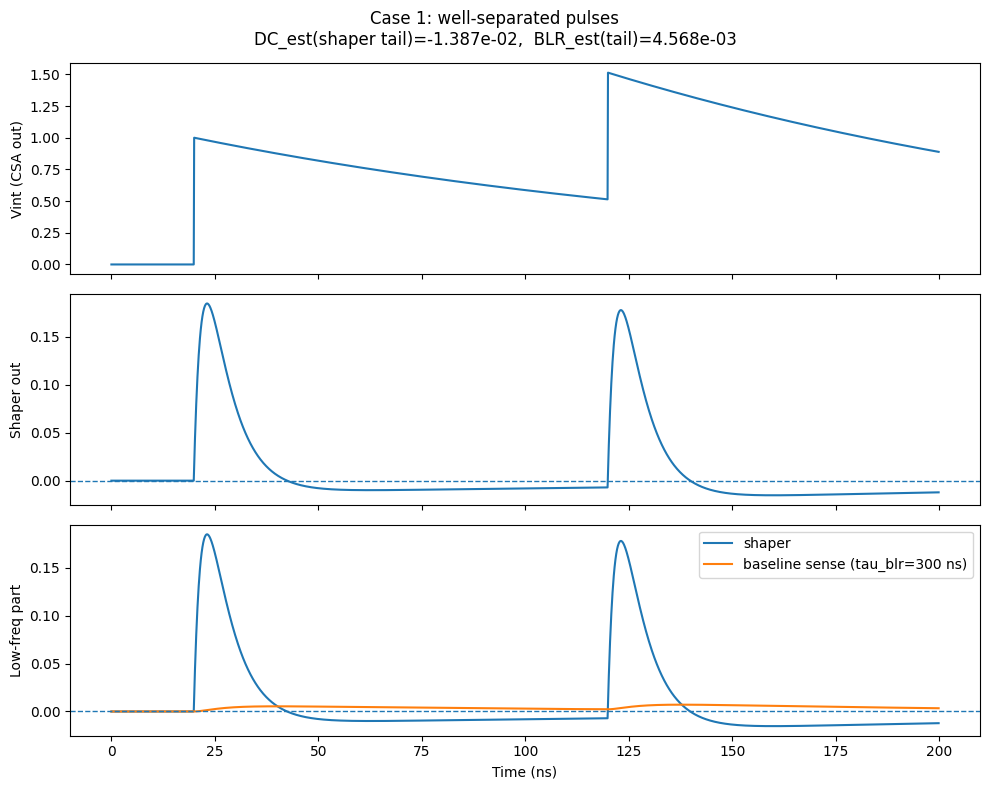

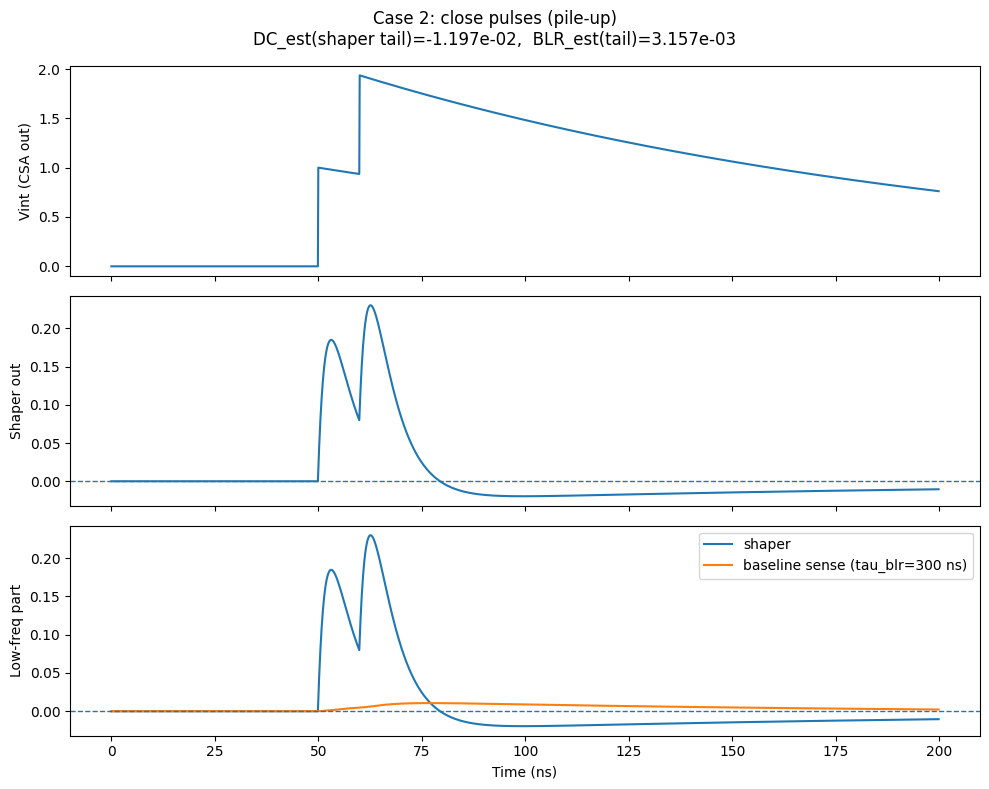

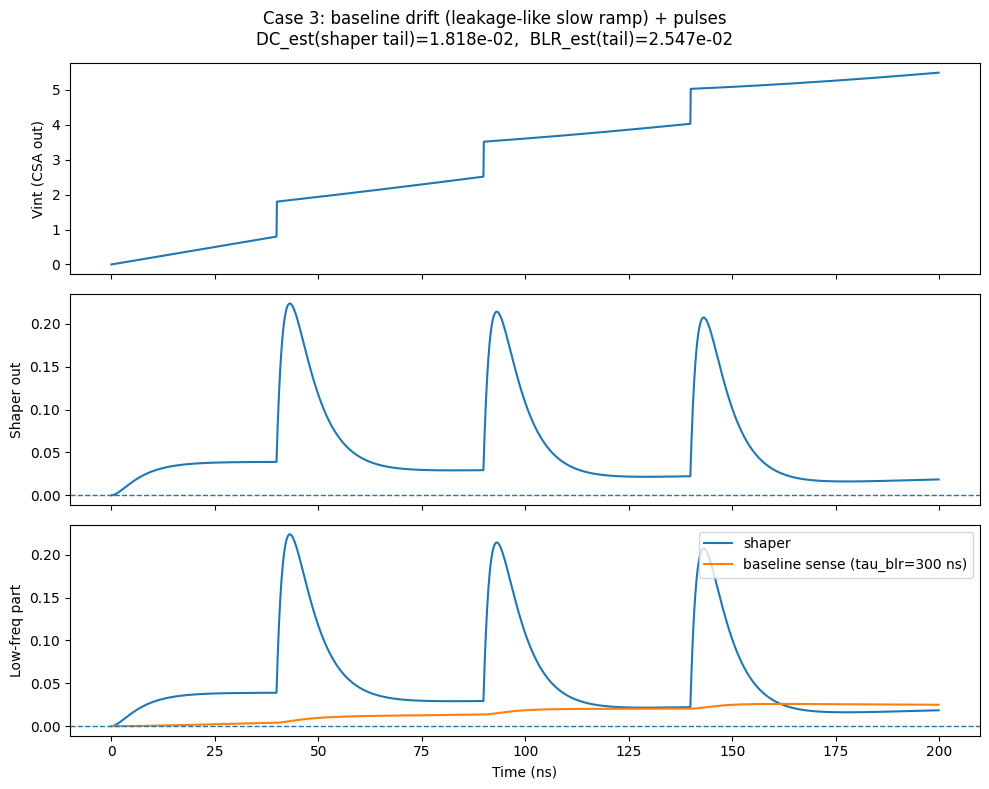

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) 你已有的 CR / RC 离散滤波器
# ----------------------------
def cr_filter(x, dt, tau_cr):
    """一阶高通（CR）"""
    a = np.exp(-dt / tau_cr)
    y = np.zeros_like(x, dtype=float)
    for n in range(1, len(x)):
        y[n] = a * (y[n-1] + x[n] - x[n-1])
    return y

def rc_filter(x, dt, tau_rc):
    """一阶低通（RC）"""
    a = np.exp(-dt / tau_rc)
    y = np.zeros_like(x, dtype=float)
    for n in range(1, len(x)):
        y[n] = a * y[n-1] + (1 - a) * x[n]
    return y

def shaper_cr_rc(vint, dt, tau_cr, tau_rc):
    return rc_filter(cr_filter(vint, dt, tau_cr), dt, tau_rc)

# ----------------------------
# 2) 生成 Vint：事件“台阶注入” + 指数回落（CSA 等效）
#    这等价于：Vint[n] = a*Vint[n-1] + sum(pulses_at_n)
# ----------------------------
def integrate_with_decay(event_times, V_pulse, t_axis, dt, tau_decay):
    a = np.exp(-dt / tau_decay)
    vint = np.zeros_like(t_axis, dtype=float)

    # 把事件时间映射到采样点
    idxs = np.round(np.asarray(event_times) / dt).astype(int)
    valid = (idxs >= 0) & (idxs < len(t_axis))
    idxs = idxs[valid]
    V_pulse = np.asarray(V_pulse)[valid]

    # 每个采样点叠加在该点发生的“台阶”
    inj = np.zeros_like(t_axis, dtype=float)
    for i, dv in zip(idxs, V_pulse):
        inj[i] += dv

    for n in range(1, len(t_axis)):
        vint[n] = a * vint[n-1] + inj[n]
    return vint

# ----------------------------
# 3) 从 shaper 输出提取“直流/基线偏移”：很慢的低通（BLR sense）
# ----------------------------
def baseline_sense(y, dt, tau_blr):
    """用很慢的一阶低通提取低频分量（近似 BLR 看到的基线漂移）"""
    return rc_filter(y, dt, tau_blr)

# ----------------------------
# 4) 工具：画图比较
# ----------------------------
def run_case(title, event_times, amps, dt=0.1e-9, T=200e-9,
             tau_decay=150e-9, tau_cr=2e-9, tau_rc=6e-9,
             tau_blr=200e-9, add_leak_current=0.0):
    """
    add_leak_current: 等效“漏电流”造成的持续斜坡/偏移（单位：V/s）
                      比如 1e6 表示每秒漂移 1e6 V（只是模型项，实际你会更小）
    """
    t = np.arange(0, T, dt)

    # 生成 CSA 输出 Vint（台阶注入+指数回落）
    vint = integrate_with_decay(event_times, amps, t, dt, tau_decay)

    # 人为加入一个慢漂移项（模拟漏电流/偏置引起的基线漂移）
    vint = vint + add_leak_current * (t - t[0])

    # CR-RC 整形
    y = shaper_cr_rc(vint, dt, tau_cr, tau_rc)

    # “BLR 看到的”基线（低频分量）
    bl = baseline_sense(y, dt, tau_blr)

    # 用稳健一点的方式给出“偏移量”指标：最后一段的均值
    tail = int(0.2 * len(t))
    dc_est = np.mean(y[-tail:])
    bl_est = np.mean(bl[-tail:])

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(f"{title}\nDC_est(shaper tail)={dc_est:.3e},  BLR_est(tail)={bl_est:.3e}", fontsize=12)

    axes[0].plot(t*1e9, vint)
    axes[0].set_ylabel("Vint (CSA out)")

    axes[1].plot(t*1e9, y)
    axes[1].axhline(0, linestyle="--", linewidth=1)
    axes[1].set_ylabel("Shaper out")

    axes[2].plot(t*1e9, y, label="shaper")
    axes[2].plot(t*1e9, bl, label=f"baseline sense (tau_blr={tau_blr*1e9:.0f} ns)")
    axes[2].axhline(0, linestyle="--", linewidth=1)
    axes[2].set_ylabel("Low-freq part")
    axes[2].set_xlabel("Time (ns)")
    axes[2].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

# ----------------------------
# 5) 运行三个典型情形：远间隔 / 近间隔(pile-up) / 带慢漂移(模拟漏电)
# ----------------------------

dt = 0.1e-9
T  = 200e-9

# 你可以把这理解成 V_pulse = Q/Cf 的离散幅度（电压台阶）
A = 1.0

# 情形1：两个事件间隔很大（基本不重叠）
run_case(
    "Case 1: well-separated pulses",
    event_times=[20e-9, 120e-9],
    amps=[A, A],
    dt=dt, T=T,
    tau_decay=150e-9,   # 你可以改成 50e-6 看“长尾世界”
    tau_cr=2e-9,
    tau_rc=6e-9,
    tau_blr=300e-9
)

# 情形2：两个事件很近（pile-up），看看 Vint 与 shaper 输出如何叠加
run_case(
    "Case 2: close pulses (pile-up)",
    event_times=[50e-9, 60e-9],   # 10ns 间隔
    amps=[A, A],
    dt=dt, T=T,
    tau_decay=150e-9,
    tau_cr=2e-9,
    tau_rc=6e-9,
    tau_blr=300e-9
)

# 情形3：加一个很慢的漂移（等效漏电/偏置），看 shaper 的低频分量如何“偏离0”
run_case(
    "Case 3: baseline drift (leakage-like slow ramp) + pulses",
    event_times=[40e-9, 90e-9, 140e-9],
    amps=[A, A, A],
    dt=dt, T=T,
    tau_decay=150e-9,
    tau_cr=2e-9,
    tau_rc=6e-9,
    tau_blr=300e-9,
    add_leak_current=2e7  # 只是演示用，调大/调小看效果
)

# 可选：你也可以试试把 tau_decay 改成 50us，看“教材型长尾”
# run_case("Case 4: textbook-like long decay (50 us)", [50e-9, 60e-9], [A, A],
#          dt=dt, T=T, tau_decay=50e-6, tau_cr=2e-9, tau_rc=6e-9, tau_blr=300e-9)
